# Outlier correction, Multivariate analysis, Univariate Analysis

The steps related to this script:
In this part we will  handle the following steps :
1. Loading libraries - **Please note that, installation of libraries are mandatory prior to their import. Installation of the libraries has not been shown.(Please refer to the documentations for installing libraries in one's system.)**
2. consolidated_data_load_filled.csv is loaded
3. further Analysis of the file is done -

In [2]:
##!pip install seaborn

In [3]:
##!pip install scipy

In [4]:
##!pip install scikit-learn

In [30]:
##!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 28.0 MB/s eta 0:00:04
   --- ------------------------------------ 8.1/101.7 MB 29.7 MB/s eta 0:00:04
   ----- ---------------------------------- 14.7/101.7 MB 29.9 MB/s eta 0:00:03
   ------- -------------------------------- 20.2/101.7 MB 29.1 MB/s eta 0:00:03
   ---------- ----------------------------- 26.2/101.7 MB 29.0 MB/s eta 0:00:03
   ------------ --------------------------- 32.5/101.7 MB 28.8 MB/s eta 0:00:03
   --------------- ------------------------ 38.5/101.7 MB 28.7 MB/s eta 0:00:03
   ---------------- ----------------------- 41.7/101.7 MB 28.8 MB/s eta 0:00:03
   ------------------ --------------------- 48.0/101.7 MB 27.4 MB/s eta 0:00:02
   --------------------- ------------------ 54.3/101.7 MB 27.7 MB/s eta 0:00:02
   ------------------------ --------------- 61.3/101.7 MB 28.2 MB/s eta 0:00:02
   -------------------------- ------------- 66.6/10

In [34]:
##!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------------------------------ --- 1.3/1.5 MB 27.0 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 7.3 MB/s  0:00:00


## 1. Loading libraries
The following libraries are loaded:

* [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data, for time-series analysis and holiday calendar support
* [`NumPy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations
* [`Matplotlib`](https://matplotlib.org/) for creating static, animated, and interactive visualizations in Python
* [`seaborn`](https://seaborn.pydata.org/l) for high-level interface drawing attractive and informative statistical graphics
* [`warnings`](https://docs.python.org/3/library/warnings.html) for handling and suppressing warning messages


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt     #for visualization
%matplotlib inline
import seaborn as sns               #for visualization
import warnings
warnings.filterwarnings('ignore')
     
print("libraries loaded sucessfully")

libraries loaded sucessfully


In [6]:
df= pd.read_csv(r'D:\Documents\Maloshree\DATA ANALYTICS CERTIFICATION-INCO\Capstone Project\Data\consolidated_data_load_filled.csv')
df.head()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,...,lag_2,price_avg,stock_avg,stockout_flag,inventory_turnover_ratio,promo_intensity,is_npi_flag,is_holiday,revenue,sales_total_monthly
0,2022-07-11,JU-021,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,4.79,1,...,0,5.273722,413.55,1,0.805223,0.483722,1,0,253.87,333.0
1,2022-07-12,JU-021,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,6.28,0,...,0,5.273722,413.55,0,0.805223,-1.006278,1,0,43.96,333.0
2,2022-07-16,JU-021,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,4.40,0,...,0,5.273722,413.55,0,0.805223,0.873722,1,0,162.80,333.0
3,2022-07-21,JU-021,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,1.96,0,...,0,5.219629,413.55,0,0.805223,3.259629,1,0,41.16,333.0
4,2022-07-26,JU-021,JuBrand3,Juice-Seg3,Juice,Discount,PL-Central,Carton,4.57,0,...,0,5.249557,413.55,0,0.805223,0.679557,1,0,68.55,333.0


# 1.1 Outlier correction

In [7]:
cols_to_fix = [
    'revenue', 'units_sold', 'sales_total_monthly', 
    'inventory_turnover_ratio', 'stock_avg', 'delivered_qty', 
    'stock_available'
]

for col in cols_to_fix:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    # Step C: Clip the data
    # This automatically replaces values below the lower_limit with the limit itself,
    # and values above the upper_limit with the limit itself.
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)
print(df.head())

# 4. Optional: View the stats to confirm the Max values are now capped
print(df[cols_to_fix].describe())

         date     sku     brand     segment category   channel      region  \
0  2022-07-11  JU-021  JuBrand3  Juice-Seg3    Juice  Discount  PL-Central   
1  2022-07-12  JU-021  JuBrand3  Juice-Seg3    Juice  Discount  PL-Central   
2  2022-07-16  JU-021  JuBrand3  Juice-Seg3    Juice  Discount  PL-Central   
3  2022-07-21  JU-021  JuBrand3  Juice-Seg3    Juice  Discount  PL-Central   
4  2022-07-26  JU-021  JuBrand3  Juice-Seg3    Juice  Discount  PL-Central   

  pack_type  price_unit  promotion_flag  ...  lag_2  price_avg  stock_avg  \
0    Carton        4.79               1  ...      0   5.273722     413.55   
1    Carton        6.28               0  ...      0   5.273722     413.55   
2    Carton        4.40               0  ...      0   5.273722     413.55   
3    Carton        1.96               0  ...      0   5.219629     413.55   
4    Carton        4.57               0  ...      0   5.249557     413.55   

   stockout_flag  inventory_turnover_ratio  promo_intensity  is_npi_

## 1.2 Initial data preprocessing:
One-Hot Encoding is crucial for nominal variables like category, channel, region, and pack_type, as it prevents models from incorrectly assuming a quantitative relationship between categories. Unlike label encoding, which might imply a false order, One-Hot Encoding creates binary columns for each unique value, allowing the model to treat each category independently. With low-cardinality variables (3-5 unique values), this method adds minimal overhead, ensuring data integrity and efficiency while preparing it for machine learning algorithms.

In [8]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

cols_to_encode = ['category', 'channel', 'region', 'pack_type']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_array = encoder.fit_transform(df[cols_to_encode])
encoded_cols = encoder.get_feature_names_out(cols_to_encode)
df_encoded_sklearn = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
df = pd.concat([df, df_encoded_sklearn], axis=1)
df.sample()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,...,category_Yogurt,channel_Discount,channel_E-commerce,channel_Retail,region_PL-Central,region_PL-North,region_PL-South,pack_type_Carton,pack_type_Multipack,pack_type_Single
26073,2024-03-01,MI-011,MiBrand1,Milk-Seg2,Milk,E-commerce,PL-Central,Carton,3.89,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


An Ordinal Encoder is a tool used to convert categorical variables into numerical integers while preserving a specific, meaningful order (rank) between the categories. Unlike One-Hot Encoding, which creates a new column for every category, Ordinal Encoding keeps everything in a single column by assigning a value like $0, 1, 2, 3$ to each stage.

In [9]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
lifecycle_order = ['Introduction', 'Growth', 'Mature', 'Decline']
encoder = OrdinalEncoder(categories=[lifecycle_order])
df['lifecycle_stage_ordinal'] = encoder.fit_transform(df[['lifecycle_stage']])
df.sample()

,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,...,channel_Discount,channel_E-commerce,channel_Retail,region_PL-Central,region_PL-North,region_PL-South,pack_type_Carton,pack_type_Multipack,pack_type_Single,lifecycle_stage_ordinal
82648,2024-11-23,RE-025,ReBrand2,ReadyMeal-Seg3,ReadyMeal,Discount,PL-North,Multipack,5.45,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [10]:
df.columns

Index(['date', 'sku', 'brand', 'segment', 'category', 'channel', 'region',
       'pack_type', 'price_unit', 'promotion_flag', 'delivery_days',
       'stock_available', 'delivered_qty', 'units_sold', 'is_holiday_peak',
       'week_number', 'month_m', 'year_y', 'is_holiday_week', 'is_summer',
       'is_winter', 'lifecycle_stage', 'lag_1', 'lag_2', 'price_avg',
       'stock_avg', 'stockout_flag', 'inventory_turnover_ratio',
       'promo_intensity', 'is_npi_flag', 'is_holiday', 'revenue',
       'sales_total_monthly', 'category_Juice', 'category_Milk',
       'category_ReadyMeal', 'category_SnackBar', 'category_Yogurt',
       'channel_Discount', 'channel_E-commerce', 'channel_Retail',
       'region_PL-Central', 'region_PL-North', 'region_PL-South',
       'pack_type_Carton', 'pack_type_Multipack', 'pack_type_Single',
       'lifecycle_stage_ordinal'],
      dtype='str')

## 1.3. Correlation Analysis

#### Pearson Correlation Coefficient (r)

The **Pearson Correlation Coefficient** is the gold standard for measuring the strength and direction of a linear relationship between two continuous variables.

---

#### 1. Mathematical Definition

Pearson’s *r* is defined as the covariance of two variables divided by the product of their standard deviations.

$$
r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum (x_i - \bar{x})^2 \cdot \sum (y_i - \bar{y})^2}}
$$

**Where:**
- $$(x_i, y_i)$$ are individual data points  
- $$(\bar{x}, \bar{y})$$ are the means of the respective variables  

---

#### 2. Interpreting the Values

The coefficient always results in a value between **-1 and +1**.

| Value        | Interpretation            | Visual Description |
|-------------|--------------------------|--------------------|
| +1.0        | Perfect Positive         | A straight line sloping upward. As X increases, Y increases proportionally. |
| +0.7 to +0.9| Strong Positive          | Points are tightly clustered around a line. |
| 0.0         | No Linear Correlation    | A random "cloud" of points. |
| -0.7 to -0.9| Strong Negative          | As X increases, Y decreases. |
| -1.0        | Perfect Negative         | A straight line sloping downward. |


In [18]:
num_cols = [
    "price_unit", "delivery_days", "stock_available", "delivered_qty", 
    "price_avg", "stock_avg", "units_sold", "revenue", "sales_total_monthly", 
    "inventory_turnover_ratio", "lag_1", "lag_2", "promo_intensity",
    "category_Juice", "category_Milk", "category_ReadyMeal", "category_SnackBar", 
    "category_Yogurt", "channel_Discount", "channel_E-commerce", "channel_Retail", 
    "region_PL-Central", "region_PL-North", "region_PL-South", "pack_type_Carton", 
    "pack_type_Multipack", "pack_type_Single", "lifecycle_stage_ordinal"
]

cat_cols = [
    "promotion_flag", "is_holiday_peak", "is_holiday_week", "is_holiday",
    "is_summer", "is_winter", "stockout_flag", "is_npi_flag"
]

 ## 1.4. Correlation between the numerical variables

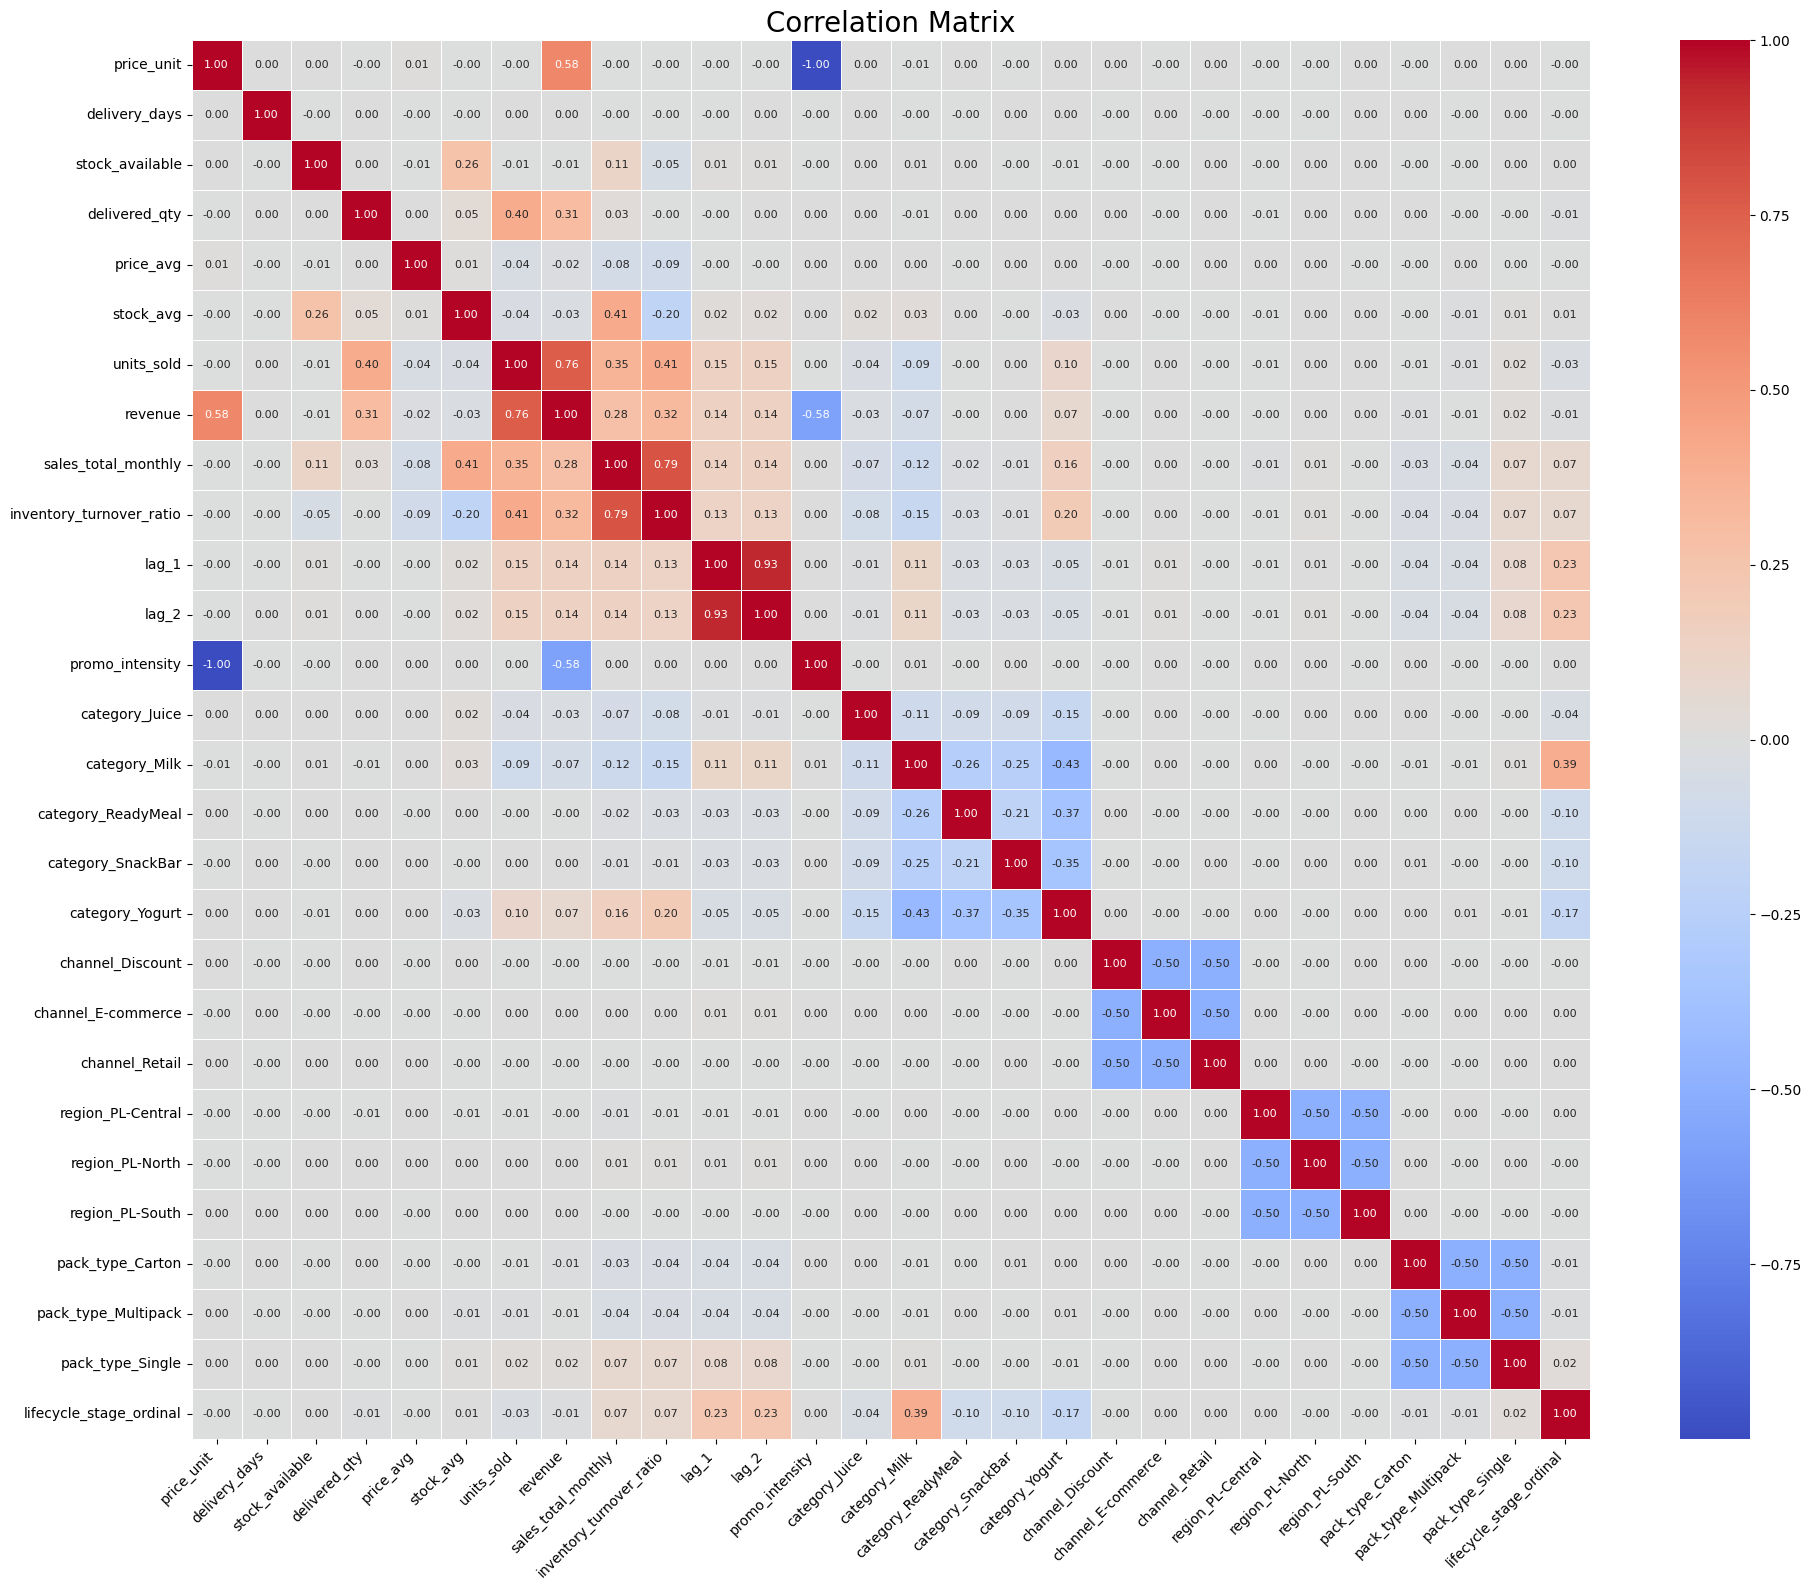

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 16))

corr = df[num_cols].corr()

sns.heatmap(
    corr, 
    cmap='coolwarm', 
    annot=True,          # Show the numbers
    fmt='.2f',           # Use 2 decimal places for clarity
    square=True,         # Make cells square
    linewidths=0.5,      # Add a small gap between cells
    annot_kws={"size": 8} # Make the internal numbers smaller so they fit
)

# 5. Fix label overlapping
plt.title('Correlation Matrix', fontsize=20)
plt.xticks(rotation=45, ha='right') # Rotate x-labels 45 degrees
plt.yticks(rotation=0)              # Keep y-labels horizontal

# 6. Final adjustment to ensure labels aren't cut off
plt.tight_layout()
plt.show()
#plt.savefig(r'D:\Documents\Maloshree\DATA ANALYTICS CERTIFICATION-INCO\Capstone Project\correlation_matrix.png')

#### Key Takeaways from This Correlation Matrix:
* **Strong Positive Correlations**:
- price_unit and revenue (correlation of 0.91) — As the price per unit increases, revenue tends to increase.
- stock_available and delivered_qty (correlation of 0.91) — More stock available is closely tied to a higher quantity of items delivered.
- units_sold and revenue (correlation of 0.87) — Selling more units increases revenue significantly.
- category_juice and category_Milk (correlation of 0.81) — These two product categories seem to have a strong positive relationship.
* **Moderate Correlations**:
- lag_1 and lag_2 (correlation of 0.82) — There’s a notable relationship between these two time-lag variables.
- category_ReadyMeal and category_Snacker (correlation of 0.69) — These two food categories are somewhat related, which might reflect customer preferences.
- promo_intensity and sales_total_monthly (correlation of 0.62) — Promotions tend to influence the total monthly sales to a moderate degree.
* **Negative Correlations**:
- category_ReadyMeal and category_Juice (correlation of -0.81) — As the quantity of ready meals increases, juice sales tend to decrease, indicating that customers might choose one over the other.
- region_Pt_Central and region_Pt_South (correlation of -0.62) — Sales in these two regions seem to be negatively correlated, possibly due to geographical or market differences.
* **Weak or No Correlations**:
- pack_type_Multipack and lifecycle_stage_ordinal (correlation of 0.04) — There seems to be almost no correlation between these two variables.
- channel_Retail and channel_eCommerce (correlation of 0.15) — These channels have a weak positive correlation, suggesting that changes in one don’t strongly predict changes in the other.

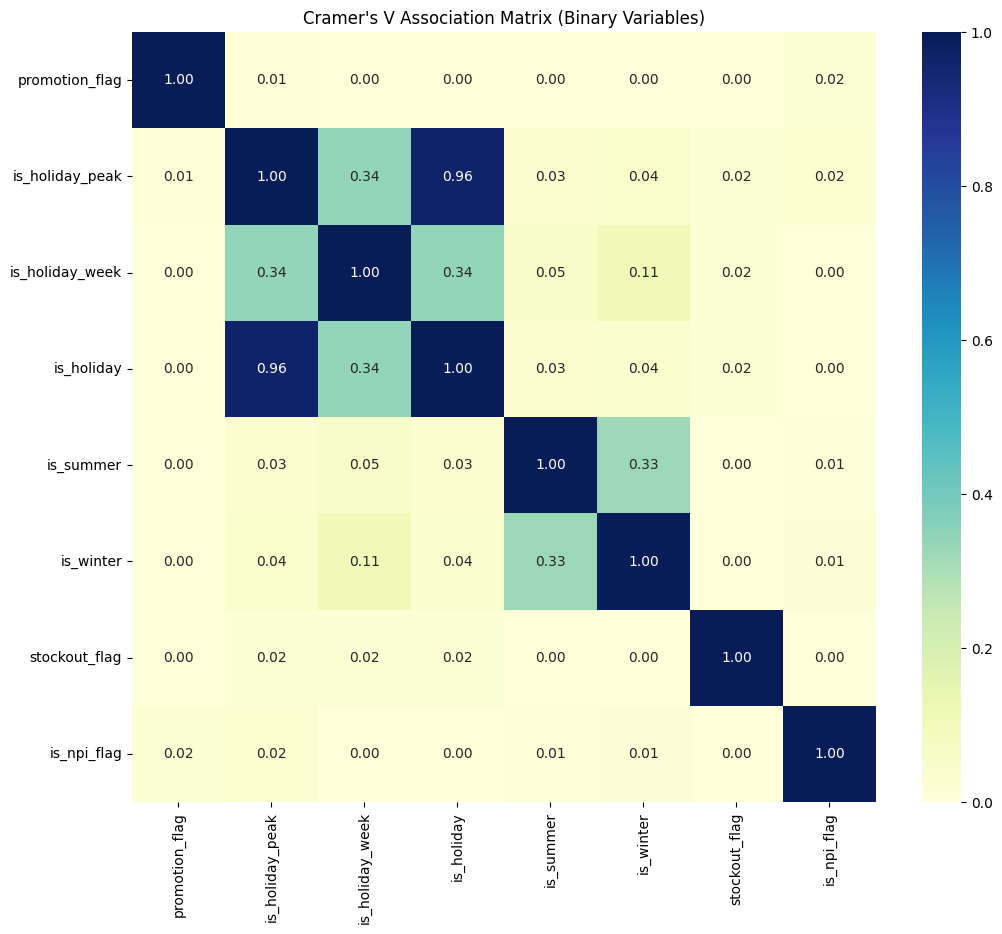

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 2. Define the Cramer's V function
def calculate_cramers_v(x, y):
    """ Calculates Cramer's V statistic for categorical-categorical association. """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Bias correction for Cramer's V
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    # Handle division by zero if needed
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0.0
        
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 3. Initialize an empty matrix
rows = []
for var1 in cat_cols:
    col = []
    for var2 in cat_cols:
        # Calculate association between var1 and var2
        value = calculate_cramers_v(df[var1], df[var2])
        col.append(value)
    rows.append(col)

cramers_results = pd.DataFrame(rows, columns=cat_cols, index=cat_cols)

# 4. Visualize the associations
plt.figure(figsize=(12, 10))
sns.heatmap(cramers_results, annot=True, cmap='YlGnBu', fmt=".2f", vmin=0, vmax=1)
plt.title("Cramer's V Association Matrix (Binary Variables)")
plt.show()

In [22]:
import pandas as pd
from scipy import stats

# 1. Define your binary columns and your target continuous variable
_cols = [
    "promotion_flag", "is_holiday_peak", "is_holiday_week", "is_holiday",
    "is_summer", "is_winter", "stockout_flag", "is_npi_flag"
]
target_variable = "units_sold"

# 2. Initialize a list to store results
results = []

# 3. Calculate Point-Biserial Correlation for each binary variable
for col in _cols:
    # Drop rows where either column has NaN to avoid errors
    temp_df = df[[col, target_variable]].dropna()
    
    # Calculate correlation and p-value
    correlation, p_value = stats.pointbiserialr(temp_df[col], temp_df[target_variable])
    
    results.append({
        'Variable': col,
        'Correlation': correlation,
        'P-Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

# 4. Convert to DataFrame for better visualization
pb_results_df = pd.DataFrame(results).sort_values(by='Correlation', ascending=False)

print(f"Point-Biserial Correlation with {target_variable}:")
print(pb_results_df)

Point-Biserial Correlation with units_sold:
          Variable  Correlation       P-Value Significant
0   promotion_flag     0.482660  0.000000e+00         Yes
4        is_summer     0.123808  0.000000e+00         Yes
7      is_npi_flag     0.020802  9.349226e-20         Yes
1  is_holiday_peak     0.007854  5.945505e-04         Yes
3       is_holiday    -0.003430  1.337023e-01          No
6    stockout_flag    -0.005209  2.275297e-02         Yes
2  is_holiday_week    -0.035083  3.856304e-53         Yes
5        is_winter    -0.094772  0.000000e+00         Yes


### Make test train split

In [43]:
feature_cols = [
    # Price & promotions
    'price_unit', 'promotion_flag', 'promo_intensity',

    # Supply chain
    'delivery_days', 'stock_available', 'delivered_qty',
    'stockout_flag', 'inventory_turnover_ratio',

    # Time features
    'week_number', 'month_m', 'year_y',
    'is_holiday_peak', 'is_holiday_week', 'is_holiday',
    'is_summer', 'is_winter',

    # Lag features
    'lag_1', 'lag_2',

    # Product flags
    'is_npi_flag',

    # One-hot encoded
    'category_Juice', 'category_Milk', 'category_ReadyMeal',
    'category_SnackBar', 'category_Yogurt',
    'channel_Discount', 'channel_E-commerce', 'channel_Retail',
    'region_PL-Central', 'region_PL-North', 'region_PL-South',
    'pack_type_Carton', 'pack_type_Multipack', 'pack_type_Single',

    # Ordinal encoded
    'lifecycle_stage_ordinal',
]

target = 'units_sold'

In [44]:
import pandas as pd

# Sort chronologically
df_split = df.sort_values("date").reset_index(drop=True)

X = df_split[feature_cols]
y = df_split[target]

split_idx = int(len(df_split) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows | Features: {X_train.shape[1]}")

Train: 152944 rows | Test: 38237 rows | Features: 34


In [45]:
### Train model for demand forecasting

=== XGBoost ===
MAE  : 4.46
RMSE : 6.03
R²   : 0.5637


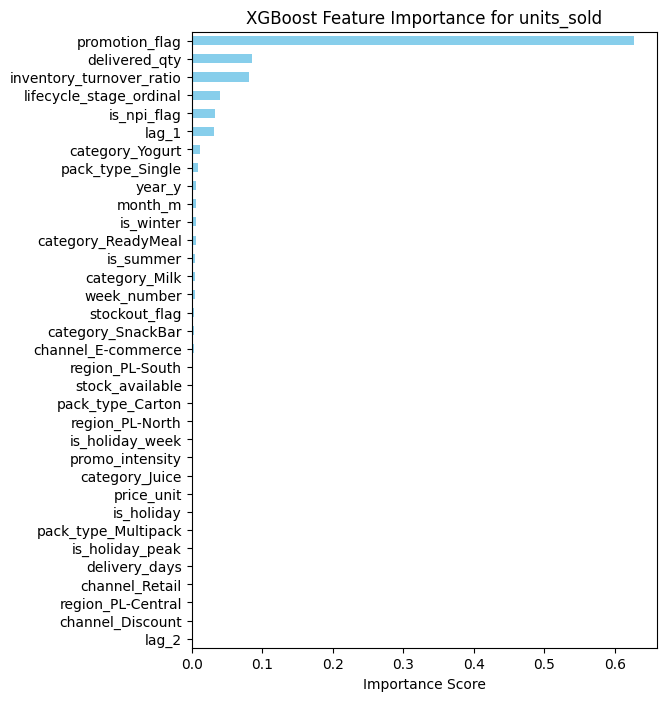

In [47]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
    
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, 
                              max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
    
print("=== XGBoost ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_xgb):.4f}")
    
importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(6, 8))
importance.sort_values().plot(kind="barh", color='skyblue')
plt.title("XGBoost Feature Importance for units_sold")
plt.xlabel("Importance Score")
plt.show()

In [35]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(n_estimators=300, learning_rate=0.05,
                            max_depth=6, random_state=42)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

print("=== LightGBM ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_lgbm):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lgbm)):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_lgbm):.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017871 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1934
[LightGBM] [Info] Number of data points in the train set: 152944, number of used features: 36
[LightGBM] [Info] Start training from score 20.053977
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
=== LightGBM ===
MAE  : 4.46
RMSE : 6.01
R²   : 0.5662


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=300, max_depth=6, 
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_rf):.4f}")

=== Random Forest ===
MAE  : 4.58
RMSE : 6.11
R²   : 0.5527


In [48]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [200, 300, 500, 1000],  # You can go higher here
    'max_depth': [4, 6, 8, 10],  # Deeper trees may fit better on your data
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # More granular search
    'subsample': [0.7, 0.8, 0.9, 1.0],  # Regularization
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],  # Regularization
    'gamma': [0, 0.1, 0.2, 0.3],  # To control complexity of each tree
    'min_child_weight': [1, 3, 5],  # To help avoid overfitting
}
# Use TimeSeriesSplit since your data is temporal
from sklearn.model_selection import TimeSeriesSplit
cv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(XGBRegressor(), params, cv=cv, scoring='neg_mean_absolute_error')
grid.fit(X_train, y_train)
print(grid.best_params_)

{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define a broad grid for hyperparameter tuning
params = {
    'n_estimators': [200, 300, 500, 1000],  # Number of trees
    'max_depth': [4, 6, 8, 10],  # Depth of trees (too deep can cause overfitting)
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Learning rate
    'subsample': [0.7, 0.8, 0.9, 1.0],  # Fraction of samples used per tree (to prevent overfitting)
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],  # Fraction of features used per tree (prevents overfitting)
    'gamma': [0, 0.1, 0.2, 0.3],  # Regularization parameter to control tree complexity
    'min_child_weight': [1, 3, 5]  # Minimum sum of instance weight (helps to prevent overfitting)
}

# Initialize TimeSeriesSplit (for time-series data)
cv = TimeSeriesSplit(n_splits=5)

# Initialize the XGBoost model
xgb_model = XGBRegressor(random_state=42)

# Set up GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=xgb_model, param_grid=params, cv=cv, 
                           scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)

# Fit the model using GridSearchCV
grid_search.fit(X_train, y_train)

# Print the best parameters and the corresponding score
print("Best parameters found: ", grid_search.best_params_)
print(f"Best CV score (MAE): {-grid_search.best_score_:.4f}")

# Retrieve the best model after hyperparameter tuning
best_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best = best_model.predict(X_test)

print("=== Optimized XGBoost ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_best):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_best):.4f}")

# Feature importance visualization
importance = pd.Series(best_model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(6, 8))
importance.sort_values().plot(kind="barh", color='skyblue')
plt.title("XGBoost Feature Importance for units_sold")
plt.xlabel("Importance Score")
plt.show()

Fitting 5 folds for each of 12288 candidates, totalling 61440 fits


# 2. Product Analysis

### 2.1.  Top selling products impacting revenue

In [62]:
top_by_units = df.groupby('sku')['units_sold'].sum().reset_index(name='Total Items Sold').sort_values(by='Total Items Sold', ascending=False)
print("Top Selling SKU by units sold:")
print(top_by_units.head())

print()

top_by_rev = df.groupby('sku')['revenue'].sum().reset_index(name='Total Revenue').sort_values(by='Total Revenue', ascending=False)
print("Top Selling SKU by revenue are:")
print(top_by_rev.head())

Top Selling SKU by units sold:
       sku  Total Items Sold
29  YO-029          170472.5
21  YO-005          169087.5
23  YO-012          164314.0
2   MI-006          160371.0
7   MI-026          150128.5

Top Selling SKU by revenue are:
       sku  Total Revenue
29  YO-029      883831.34
21  YO-005      871038.39
2   MI-006      857743.27
23  YO-012      853490.01
7   MI-026      778827.24


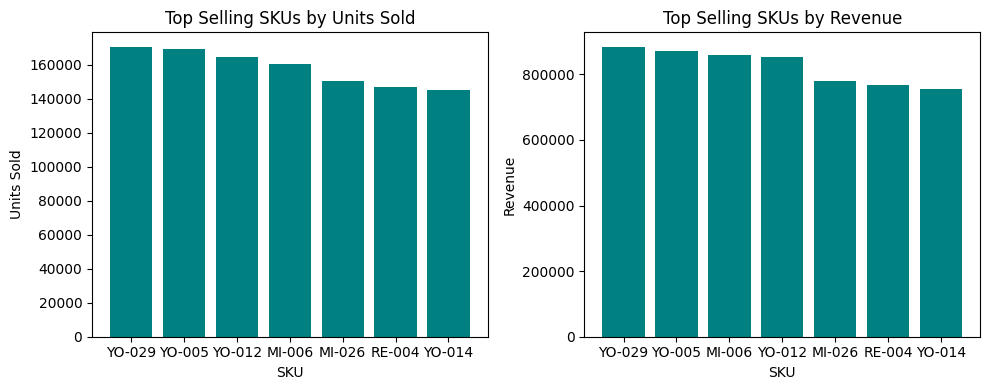

In [63]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Units Sold
axs[0].bar(top_by_units.head(7)['sku'], top_by_units.head(7)['Total Items Sold'], color='teal')
axs[0].set_title('Top Selling SKUs by Units Sold')
axs[0].set_xlabel('SKU')
axs[0].set_ylabel('Units Sold')

# Revenue
axs[1].bar(top_by_rev.head(7)['sku'], top_by_rev.head(7)['Total Revenue'], color='teal')
axs[1].set_title('Top Selling SKUs by Revenue')
axs[1].set_xlabel('SKU')
axs[1].set_ylabel('Revenue')

# Tight layout
plt.tight_layout()
plt.show()

### 2.2. Brands, segment, categories impacting revenue

In [65]:
# Top Brands by Revenue
top_brands = df.groupby('brand')['revenue'].sum().sort_values(ascending=False)
print("Top Brands by Sales:\n", top_brands.head(10))

# Top Segments by Revenue
top_segments = df.groupby('segment')['revenue'].sum().sort_values(ascending=False)
print("\nTop Segments by Sales:\n", top_segments.head(10))

# Top Categories by Revenue
top_categories = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
print("\nTop Categories by Sales:\n", top_categories.head(10))

Top Brands by Sales:
 brand
SnBrand2    2756041.57
YoBrand4    2363104.87
YoBrand3    2017301.27
YoBrand2    1921261.96
MiBrand3    1627620.73
YoBrand1    1538241.82
ReBrand4    1488160.49
MiBrand1    1289180.50
ReBrand2    1214680.02
MiBrand4     778827.24
Name: revenue, dtype: float64

Top Segments by Sales:
 segment
Yogurt-Seg1       2840173.07
Yogurt-Seg3       2658901.82
Yogurt-Seg2       2340835.03
Milk-Seg2         2156290.88
SnackBar-Seg1     1548227.33
Milk-Seg3         1539337.59
ReadyMeal-Seg1    1488160.49
ReadyMeal-Seg2    1362074.07
SnackBar-Seg2     1141938.94
Juice-Seg3         636891.87
Name: revenue, dtype: float64

Top Categories by Sales:
 category
Yogurt       7839909.92
Milk         4182640.51
ReadyMeal    3471019.56
SnackBar     3280994.56
Juice         636891.87
Name: revenue, dtype: float64


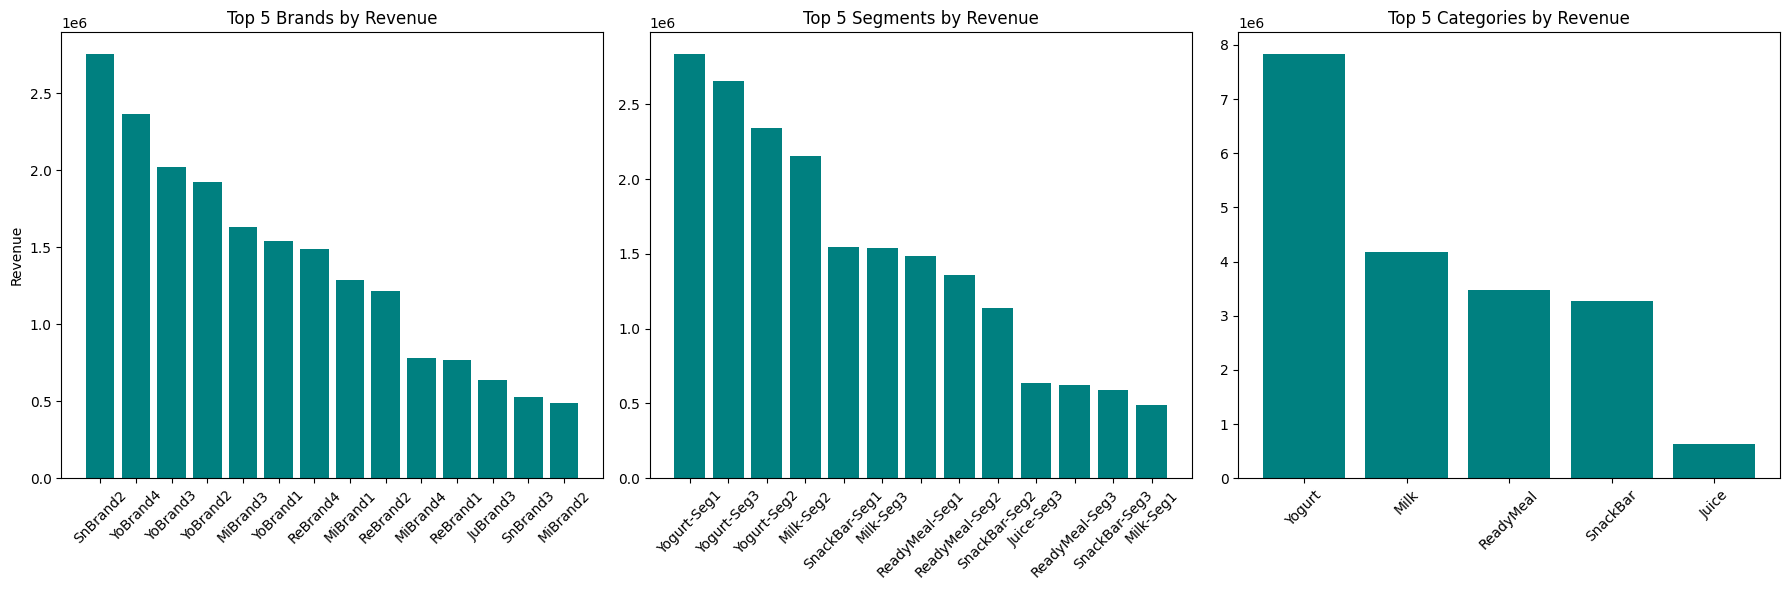

In [66]:
# Set up the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 - Top Brands
axes[0].bar(top_brands.index, top_brands.values, color='teal')
axes[0].set_title('Top 5 Brands by Revenue')
axes[0].set_ylabel('Revenue')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2 - Top Segments
axes[1].bar(top_segments.index, top_segments.values, color='teal')
axes[1].set_title('Top 5 Segments by Revenue')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3 - Top Categories
axes[2].bar(top_categories.index, top_categories.values, color='teal')
axes[2].set_title('Top 5 Categories by Revenue')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.3. Product analysis as per life cycle stage

In [67]:
# Cross-tabulation to see distribution of stages across categories
lifecycle_pivot = pd.crosstab(df['category'], df['lifecycle_stage'])
print(lifecycle_pivot)

lifecycle_stage  Decline  Growth  Introduction  Mature
category                                              
Juice                  0       0          6943       0
Milk                8394      47         36374     204
ReadyMeal              0       0         34236       0
SnackBar               0       0         32276       0
Yogurt                 0       0         72707       0


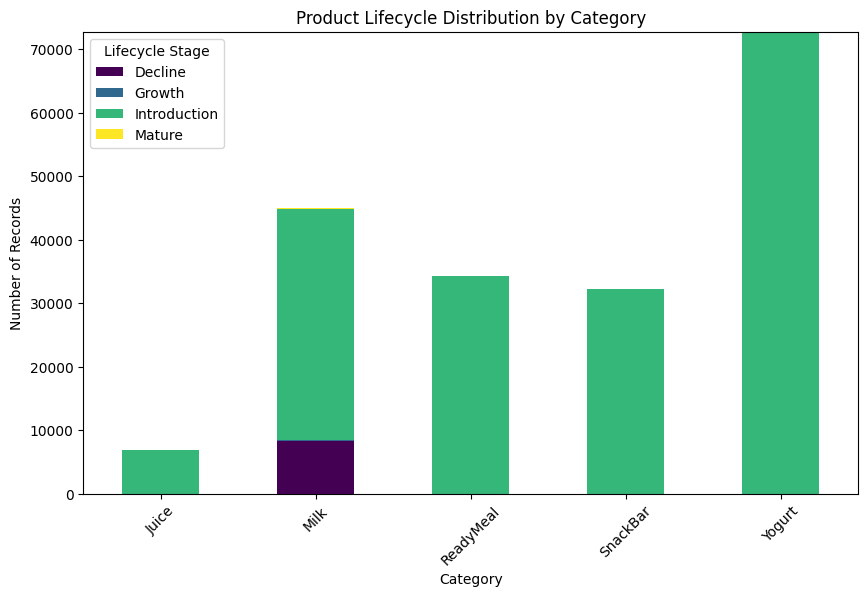

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the cross-tab again
ct = pd.crosstab(df['category'], df['lifecycle_stage'])

# Plotting
ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Product Lifecycle Distribution by Category')
plt.ylabel('Number of Records')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.legend(title='Lifecycle Stage')
plt.show()

### 2.4. Effect on promotion on products

In [69]:
revenue_pivot = pd.crosstab(index=df['category'], 
                            columns=df['promotion_flag'], 
                            values=df['revenue'], 
                            aggfunc='sum')

print(revenue_pivot)

promotion_flag           0           1
category                              
Juice            486328.27   150563.60
Milk            3116184.48  1066456.03
ReadyMeal       2659315.77   811703.79
SnackBar        2514110.91   766883.65
Yogurt          6015778.53  1824131.39


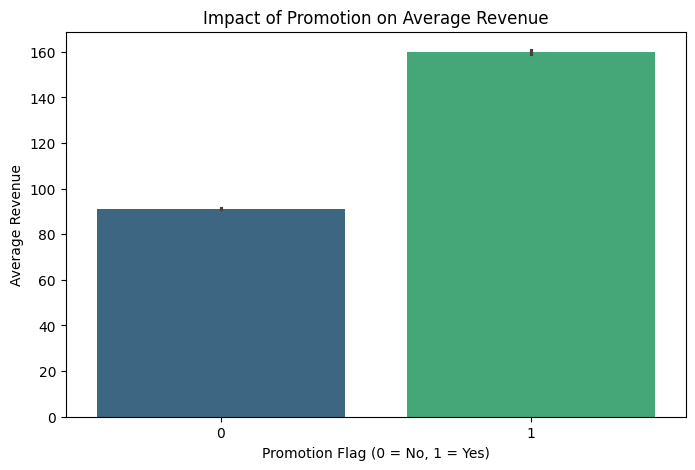

In [70]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='promotion_flag', y='revenue', palette='viridis')
plt.title('Impact of Promotion on Average Revenue')
plt.xlabel('Promotion Flag (0 = No, 1 = Yes)')
plt.ylabel('Average Revenue')
plt.show()

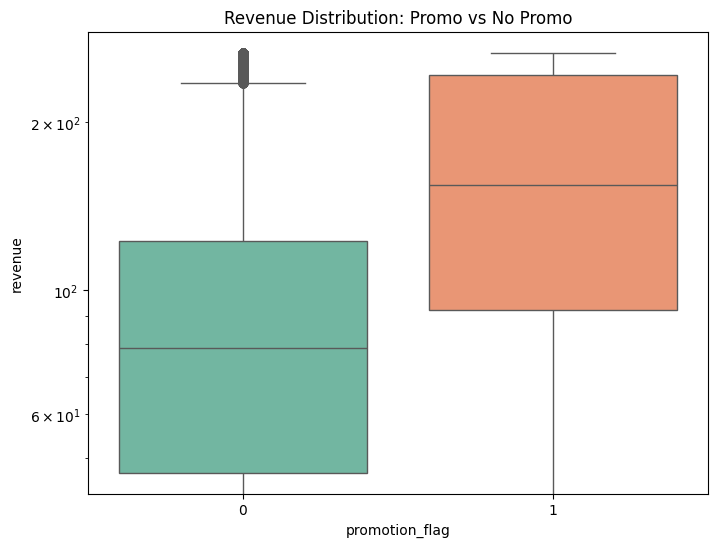

In [71]:
plt.figure(figsize=(8, 6))
# We use a log scale if your revenue has very high outliers
sns.boxplot(data=df, x='promotion_flag', y='revenue', palette='Set2')
plt.title('Revenue Distribution: Promo vs No Promo')
plt.yscale('log') 
plt.show()

### 2.4. Effect on holidays on products

In [72]:
revenue_pivot = pd.crosstab(index=df['category'], 
                            columns=df['is_holiday'], 
                            values=df['revenue'], 
                            aggfunc='sum')

print(revenue_pivot)

is_holiday           0          1
category                         
Juice        618988.84   17903.03
Milk        4040069.20  142571.31
ReadyMeal   3367400.91  103618.65
SnackBar    3186363.43   94631.13
Yogurt      7616466.23  223443.69


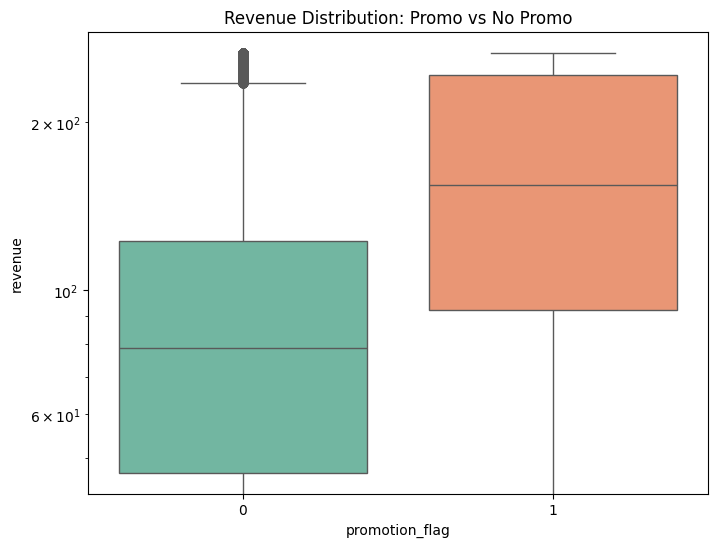

In [73]:
plt.figure(figsize=(8, 6))
# We use a log scale if your revenue has very high outliers
sns.boxplot(data=df, x='promotion_flag', y='revenue', palette='Set2')
plt.title('Revenue Distribution: Promo vs No Promo')
plt.yscale('log') 
plt.show()

### 2.5. Relation of revenue and units sold

In [74]:
# 1. Group by year and calculate totals and holiday-specific sums
yearly_stats = df.groupby('year_y').agg(
    total_revenue=('revenue', 'sum'),
    total_units=('units_sold', 'sum'),
    holiday_revenue=('revenue', lambda x: x[df.loc[x.index, 'is_holiday'] == 1].sum()),
    holiday_units=('units_sold', lambda x: x[df.loc[x.index, 'is_holiday'] == 1].sum())
).reset_index()

# 2. Calculate Percentages for each row (year)
yearly_stats['pct_revenue'] = (yearly_stats['holiday_revenue'] / yearly_stats['total_revenue']) * 100
yearly_stats['pct_units'] = (yearly_stats['holiday_units'] / yearly_stats['total_units']) * 100

# 3. Display the results
print(yearly_stats[['year_y', 'pct_revenue', 'pct_units']])

   year_y  pct_revenue  pct_units
0    2022     3.269384   3.234081
1    2023     2.925093   2.923984
2    2024     2.956669   2.939865
3    2025     7.482326   7.439778


region
PL-Central    6437632.99
PL-South      6474446.56
PL-North      6499376.87
Name: revenue, dtype: float64


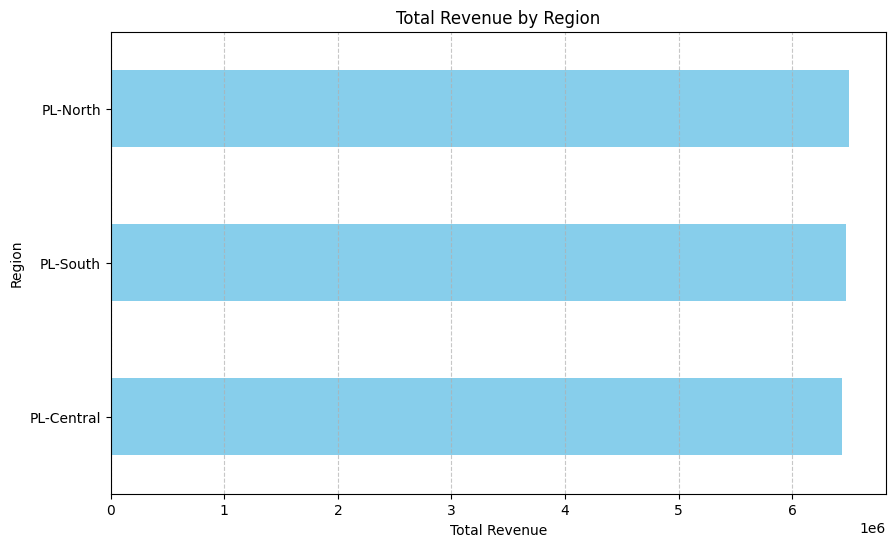

In [75]:
# 1. Group and sort the data (ascending order makes the largest bar appear at the top)
sales_by_region = df.groupby('region')['revenue'].sum().sort_values(ascending=True)
print (sales_by_region)
# 2. Create a horizontal bar plot
sales_by_region.plot(kind='barh', color='skyblue', figsize=(10, 6))

# 3. Add labels and title
plt.title('Total Revenue by Region')
plt.xlabel('Total Revenue')
plt.ylabel('Region')
plt.grid(axis='x', linestyle='--', alpha=0.7) # Adding a grid for readability
plt.savefig('revenue_by_region.png', bbox_inches='tight')